# 01b · EDA: the features

**Question.** What do the 71 flow features look like, how much independent information do they
carry, and which of them separate each attack family from benign traffic?

All statistics are descriptive. Correlations and separation scores use fixed random samples
(seeds in the code) of 200,000-300,000 flows; the full data gives the same picture.

In [1]:
import sys, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from sklearn.metrics import roc_auc_score
from src.evaluation.folds import day_key
from src.models.cross_dataset import FAMILY
from src.reporting.plots import style, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

df = pd.read_parquet("../data/processed/cicids2017_eval.parquet")
features = df.select_dtypes(include=[np.number]).columns.tolist()
df["day"] = df["Meta_source"].map(lambda s: day_key(s, "2017"))
df["family"] = df["Label"].map(FAMILY)
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
ATTACK_FAMILIES = ["Brute force (FTP/SSH)", "DoS", "Heartbleed", "Web attack", "Infiltration", "Bot", "PortScan", "DDoS"]
BLUES = LinearSegmentedColormap.from_list("blues", ["#f2f6fc", "#9ec5f4", "#3987e5", "#1c5cab", "#0d366b"])
BENIGN_C, ATTACK_C = "#2a78d6", "#eb6834"
print(f"CIC-IDS2017 evaluation copy: {len(df):,} flows, {len(features)} numeric features")

X = df[features]
identical = []
for i, a in enumerate(features):
    for b in features[i + 1:]:
        if X[a].equals(X[b]):
            identical.append((a, b))
sample = df.sample(300_000, random_state=42)
rho = sample[features].rank().corr().fillna(0)
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
dist = np.clip(1 - rho.abs().values, 0, None); np.fill_diagonal(dist, 0)
tree = linkage(squareform(dist, checks=False), "average")
groups = {t: len(set(fcluster(tree, 1 - t, "distance"))) for t in [0.99, 0.95, 0.9]}
q = X.quantile([0.5, 0.99]); zero_share = (X == 0).mean()
tails = pd.DataFrame({"zero share": zero_share, "median": q.loc[0.5], "99th pct": q.loc[0.99], "max": X.max()})
tails["max / 99th pct"] = tails["max"] / tails["99th pct"].replace(0, np.nan)
print(f"Finding: the {len(features)} features carry far less independent information than their count suggests. "
      f"{len(identical)} pairs of columns are identical in every flow, and grouping features whose rank correlation "
      f"is at least 0.95 leaves {groups[0.95]} groups. {int((zero_share > 0.5).sum())} features are zero in most "
      f"flows, and {int((tails['max / 99th pct'] > 10).sum())} have a maximum more than 10 times their 99th percentile.")

CIC-IDS2017 evaluation copy: 2,827,726 flows, 71 numeric features


Finding: the 71 features carry far less independent information than their count suggests. 4 pairs of columns are identical in every flow, and grouping features whose rank correlation is at least 0.95 leaves 42 groups. 25 features are zero in most flows, and 22 have a maximum more than 10 times their 99th percentile.


## Feature families

The features come from the CICFlowMeter tool: per-flow counts, sizes, timing and TCP-flag
statistics, computed separately for the forward (client to server) and backward directions.

In [2]:
def family_of(f):
    rules = [("Destination Port", "Flow metadata"), ("Flow Duration", "Flow metadata"), ("/s", "Rates"),
             ("IAT", "Inter-arrival times"), ("Flag", "TCP flags"), ("Init_Win", "TCP window"),
             ("Has_Init", "TCP window"), ("seg_size", "TCP window"), ("act_data", "TCP window"),
             ("Active", "Active / idle times"), ("Idle", "Active / idle times"), ("Subflow", "Subflow counts"),
             ("Header", "Header lengths"), ("Down/Up", "Ratios")]
    return next((fam for key, fam in rules if key in f), "Packet counts and sizes")
pd.Series(features).map(family_of).value_counts().rename_axis("feature family").to_frame("features")

,features
feature family,
Packet counts and sizes,20
Inter-arrival times,14
TCP flags,10
Active / idle times,8
TCP window,6
Rates,4
Subflow counts,4
Flow metadata,2
Header lengths,2


## Heavy tails

In [3]:
tails.sort_values("max / 99th pct", ascending=False).head(10).round(1)

,zero share,median,99th pct,max,max / 99th pct
Total Length of Bwd Packets,0.2,123.0,71908.0,655453030.0,9115.2
Subflow Bwd Bytes,0.2,123.0,71908.0,655453030.0,9115.2
act_data_pkt_fwd,0.3,1.0,27.0,213557.0,7909.5
Subflow Bwd Packets,0.2,2.0,57.0,291922.0,5121.4
Total Backward Packets,0.2,2.0,57.0,291922.0,5121.4
Subflow Fwd Packets,0.0,2.0,48.0,219759.0,4578.3
Total Fwd Packets,0.0,2.0,48.0,219759.0,4578.3
Bwd Header Length,0.2,40.0,1524.0,5838440.0,3831.0
Fwd Header Length,0.0,64.0,1328.0,4644908.0,3497.7
Total Length of Fwd Packets,0.2,62.0,11595.0,12900000.0,1112.5


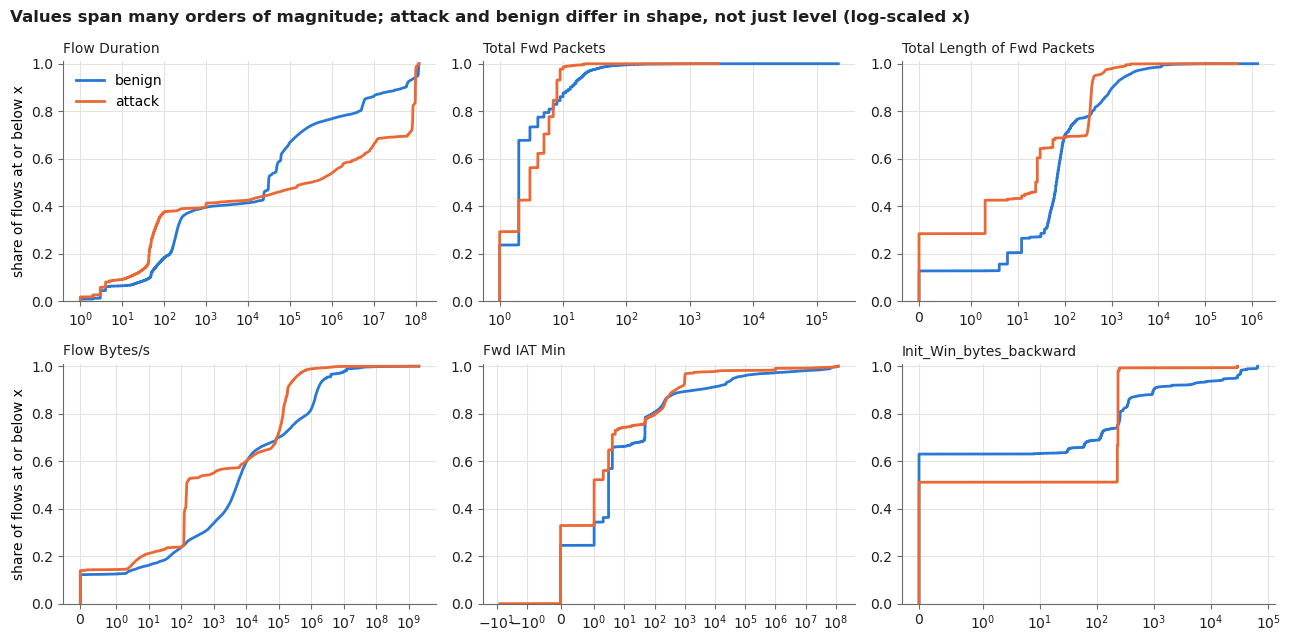

In [4]:
benign = df[df["Label"] == "BENIGN"].sample(200_000, random_state=1)
attack = df[df["Label"] != "BENIGN"].sample(200_000, random_state=1)
show = ["Flow Duration", "Total Fwd Packets", "Total Length of Fwd Packets",
        "Flow Bytes/s", "Fwd IAT Min", "Init_Win_bytes_backward"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, f in zip(axes.flat, show):
    for frame, label, color in [(benign, "benign", BENIGN_C), (attack, "attack", ATTACK_C)]:
        v = np.sort(frame[f].to_numpy())
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=color, linewidth=2, label=label)
    ax.set_xscale("symlog", linthresh=1); ax.set_ylim(0, 1.01)
    ax.set_title(f, loc="left", fontsize=10, color=INK); style(ax); ax.grid(axis="y", color="#e4e3dc")
axes[0, 0].legend(frameon=False); axes[0, 0].set_ylabel("share of flows at or below x"); axes[1, 0].set_ylabel("share of flows at or below x")
fig.suptitle("Values span many orders of magnitude; attack and benign differ in shape, not just level (log-scaled x)",
             x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout(); plt.show()

## Redundancy

Some columns are not just correlated but identical in every one of the 2.8M flows. Two of these
are suspicious rather than redundant: a SYN flag count equal to the forward PSH-flag count, and a
CWE flag count equal to the forward URG-flag count, are not plausible traffic. They point to
fields the flow tool mislabels or copies. The subflow pairs are identical because each flow here
has a single subflow.

Beyond exact copies, many features move together: timing statistics (total, mean, max of the
same inter-arrival times) and size statistics (total, mean, max of the same packets).

In [5]:
pd.DataFrame(identical, columns=["column", "identical in every flow to"])

,column,identical in every flow to
0,Total Fwd Packets,Subflow Fwd Packets
1,Total Backward Packets,Subflow Bwd Packets
2,Fwd PSH Flags,SYN Flag Count
3,Fwd URG Flags,CWE Flag Count


In [6]:
print("Independent groups of features at each rank-correlation threshold:", groups)
cl = fcluster(tree, 0.05, "distance")
big = pd.Series(features, index=cl).groupby(level=0).apply(list)
pd.DataFrame({"features with rank correlation >= 0.95": [", ".join(g) for g in big if len(g) >= 3]})

Independent groups of features at each rank-correlation threshold: {0.99: 49, 0.95: 42, 0.9: 34}


,features with rank correlation >= 0.95
0,"Bwd IAT Total, Bwd IAT Mean, Bwd IAT Max"
1,"Total Backward Packets, Bwd Header Length, Subflow Bwd Packets"
2,"Total Length of Bwd Packets, Bwd Packet Length Max, Bwd Packet Length Mean, ..."
3,"Max Packet Length, Packet Length Mean, Average Packet Size"
4,"Fwd IAT Total, Fwd IAT Mean, Fwd IAT Max"
5,"Flow Duration, Flow Packets/s, Flow IAT Mean, Flow IAT Max, Fwd Packets/s"
6,"Active Mean, Active Max, Active Min, Idle Mean, Idle Max, Idle Min"


## What separates each attack family from benign traffic

For each family and each feature, the separation score is 2 × ROC AUC − 1 of that single feature
against a benign sample: +1 means the family's values are always higher than benign, -1 always
lower, 0 no separation. The heatmap shows each family's three most separating features. This is
description, not feature selection: no model uses these scores.

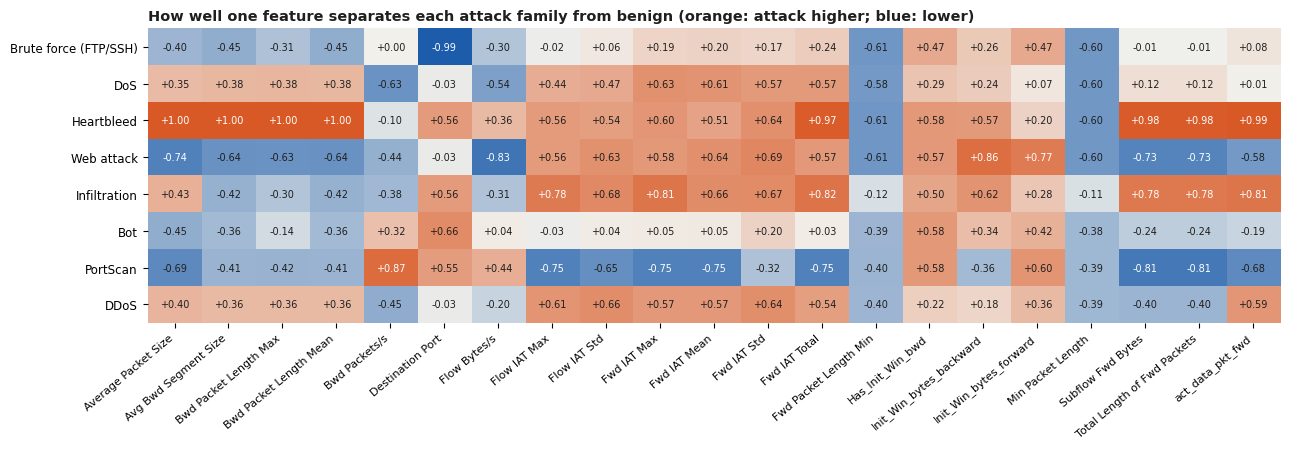

In [7]:
sep = {}
for fam in ATTACK_FAMILIES:
    rows = df[df["family"] == fam]
    rows = rows.sample(min(len(rows), 50_000), random_state=1)
    y = np.r_[np.zeros(len(benign)), np.ones(len(rows))]
    sep[fam] = {f: 2 * roc_auc_score(y, np.r_[benign[f].to_numpy(), rows[f].to_numpy()]) - 1 for f in features}
sep = pd.DataFrame(sep).T   # +1: attack always higher, -1: attack always lower, 0: no separation
top = sorted({f for fam in sep.index for f in sep.loc[fam].abs().nlargest(3).index})
diverging = LinearSegmentedColormap.from_list("div", ["#1c5cab", "#f2f1ec", "#d95926"])
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.imshow(sep[top].values, cmap=diverging, vmin=-1, vmax=1, aspect="auto")
for (i, j), v in np.ndenumerate(sep[top].values):
    ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=7, color="white" if abs(v) > 0.7 else INK)
ax.set_xticks(range(len(top))); ax.set_xticklabels(top, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(sep))); ax.set_yticklabels(sep.index, fontsize=8.5)
ax.set_title("How well one feature separates each attack family from benign (orange: attack higher; blue: lower)",
             loc="left", fontweight="bold", color=INK, fontsize=10.5)
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()

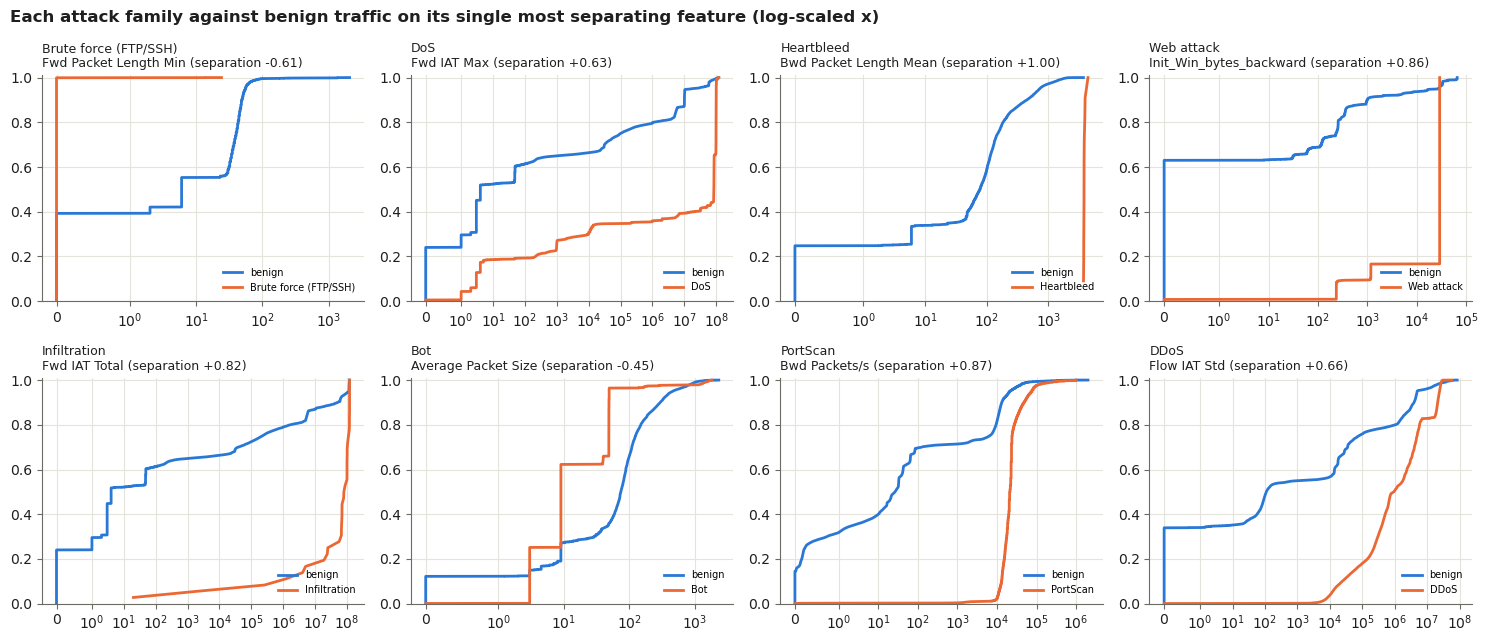

In [8]:
# Each family against benign on its most separating continuous feature
# (destination port is a category and yes/no indicators make a single step, so both are excluded)
not_continuous = ["Destination Port"] + [f for f in features if df[f].nunique() <= 2]
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, fam in zip(axes.flat, ATTACK_FAMILIES):
    f = sep.loc[fam].drop(not_continuous).abs().idxmax()
    rows = df[df["family"] == fam]
    for frame, label, color in [(benign, "benign", BENIGN_C), (rows, fam, ATTACK_C)]:
        v = np.sort(frame[f].to_numpy())
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=color, linewidth=2, label=label)
    ax.set_xscale("symlog", linthresh=1); ax.set_ylim(0, 1.01)
    ax.set_title(f"{fam}\n{f} (separation {sep.loc[fam, f]:+.2f})", loc="left", fontsize=9, color=INK)
    style(ax); ax.grid(axis="y", color="#e4e3dc")
    ax.legend(frameon=False, fontsize=7, loc="lower right")
fig.suptitle("Each attack family against benign traffic on its single most separating feature (log-scaled x)",
             x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout(); plt.show()

## What this shows

- **Far fewer signals than columns.** Four column pairs are identical, and at a rank correlation of
  0.95 the 71 features collapse into a few dozen groups. Models that report "71 features" are
  working with much less independent information.
- **Heavy tails everywhere.** Byte and packet counts span from zero to hundreds of millions, and a
  quarter of the features are zero in most flows. Scale-sensitive models (logistic regression,
  autoencoders) need log transforms; trees do not care.
- **Each family has its own fingerprint, often a lab one.** DoS and DDoS separate on packet sizes
  and timing; brute force on repeated small exchanges; web attacks and several others on the
  server's TCP window, which is a property of the victim machine rather than the attack (see
  `03_forward_2017`). Destination port separates almost every family, for the reason in `01a`.

## Limits

Single-feature separation ignores interactions, and it treats destination port as a number.